In [1]:
using VeryDiff, LinearAlgebra, Plots, JLD2
using VeryDiff: Dense, ChebyshevPoly, Network, load_network
import VeryDiff: approximate_polynomial_iterative

using VeryDiffPolyExperiments
using VeryDiffPolyExperiments: generate_poly_network

Set parameter Username
Set parameter LicenseID to value 2695178
Academic license - for non-commercial use only - expires 2026-08-12


# Code for Storing and Sharing Networks

In [2]:
function convert_to_list_of_tuples(net::Network)
    layers = []
    for layer in net.layers
        if layer isa Dense
            push!(layers, ("linear", layer.W, layer.b))
        elseif layer isa ChebyshevPoly
            push!(layers, ("chebyshev", layer.coeffs, layer.l, layer.u))
        elseif layer isa typeof(ReLU())
            push!(layers, ("relu",))
        else
            error("Unsupported layer type: $(typeof(layer))")
        end
    end
    return layers
end

convert_to_list_of_tuples (generic function with 1 method)

# Code for Merging Normalization into Layer

In [3]:
function merge_normalization_into_dense(layer_lin::Dense, layer_poly::ChebyshevPoly{N,VN}) where {N,VN}
    l, u = layer_poly.l, layer_poly.u

    a = 1 ./ (0.5 .* (u .- l))
    b = -0.5 .* (u .+ l) ./ (0.5 .* (u .- l))

    Ŵ = a .* layer_lin.W
    b̂ = a .* layer_lin.b .+ b

    n = length(l)
    return Dense(Ŵ, b̂), ChebyshevPoly(layer_poly.coeffs, -ones(N, n), ones(N, n))
end

merge_normalization_into_dense (generic function with 1 method)

In [4]:
function merge_normalization_into_dense(net::Network)
    layers = net.layers
    new_layers = Vector{Any}(undef, length(layers))

    for i in 1:2:length(layers) - 1
        layer_lin = layers[i]
        layer_poly = layers[i + 1]
        layer_lin_new, layer_poly_new = merge_normalization_into_dense(layer_lin, layer_poly)
        new_layers[i] = layer_lin_new
        new_layers[i + 1] = layer_poly_new
    end

    if isodd(length(layers))
        new_layers[end] = layers[end]
    end

    return Network(new_layers)
end

merge_normalization_into_dense (generic function with 2 methods)

## Check Validity on Example NN

In [5]:
W1 = reshape([1., 1], 2, 1)
b1 = [1, -1.]

W2 = reshape([1, -1.], 1, 2)
b2 = [0.]

nn = Network([Dense(W1, b1), ReLU(), Dense(W2, b2)])

z = Zonotope([-2.], [2.])
degree = 5
nn_poly = approximate_polynomial_iterative(nn, z, degree, cheby=true, verbosity=1, max_iter=20)

--- layer 1 ---
lower = [-2.0]
upper = [2.0]
--- layer 2 ---
lower = [-1.0, -3.0]
upper = [3.0, 1.0]
max error = 0.05859389927906322 at idx 2 with bounds -3.0 1.0
--- layer 3 ---
lower = [-0.7168036647309333, -0.716803664730933]
upper = [3.05859389927633, 1.058593899276329]


Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0; 1.0;;], [1.0, -1.0]), ChebyshevPoly{Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}([1.2159767564769026 1.6093884214893137 … 0.05820314418576433 0.047994435711259525; 0.2159767564769025 0.39061157851068623 … 0.0582031441857642 -0.047994435711259505], [-1.0, -3.0], [3.0, 1.0]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0 -1.0], [0.0])])

In [6]:
nn_poly2 = merge_normalization_into_dense(nn_poly)

Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([0.5; 0.5;;], [0.0, 0.0]), ChebyshevPoly{Float64, Vector{Float64}}([1.2159767564769026 1.6093884214893137 … 0.05820314418576433 0.047994435711259525; 0.2159767564769025 0.39061157851068623 … 0.0582031441857642 -0.047994435711259505], [-1.0, -1.0], [1.0, 1.0]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0 -1.0], [0.0])])

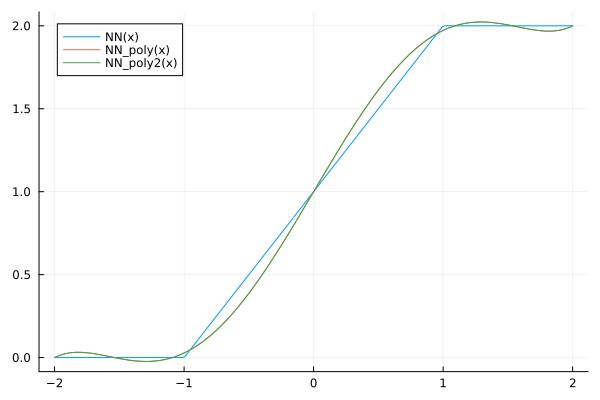

In [7]:
xs = range(-2, 2, 200)
ys = [nn([x])[1] for x in xs];
ys_poly = [nn_poly([x])[1] for x in xs];
ys_poly2 = [nn_poly2([x])[1] for x in xs];

plot(xs, ys, label="NN(x)")
plot!(xs, ys_poly, label="NN_poly(x)")
plot!(xs, ys_poly2, label="NN_poly2(x)")

They seem to compute the same function.

# Example NNs for Implementation in FHE

## Just a Single ReLU

This network just computes $\max(0,x)$.

In [8]:
W1 = reshape([1.],1, 1)
b1 = [0.]

W2 = reshape([1.], 1, 1)
b2 = [0.]

nn = Network([Dense(W1, b1), ReLU(), Dense(W2, b2)])

z = Zonotope([-2.], [2.])
degree = 5
nn_poly = approximate_polynomial_iterative(nn, z, degree, cheby=true, verbosity=1, max_iter=20)

--- layer 1 ---
lower = [-2.0]
upper = [2.0]
--- layer 2 ---
lower = [-2.0]
upper = [2.0]
max error = 0.044658198738520616 at idx 1 with bounds -2.0 2.0
--- layer 3 ---
lower = [-0.9553418012613971]
upper = [1.9564367779954268]


Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0;;], [0.0]), ChebyshevPoly{Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}([0.6220084679281463 1.0000000000000002 … -0.1220084679281462 -5.551115123125783e-18], [-2.0], [2.0]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0;;], [0.0])])

In [9]:
nn_poly2 = merge_normalization_into_dense(nn_poly)

Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([0.5;;], [0.0]), ChebyshevPoly{Float64, Vector{Float64}}([0.6220084679281463 1.0000000000000002 … -0.1220084679281462 -5.551115123125783e-18], [-1.0], [1.0]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0;;], [0.0])])

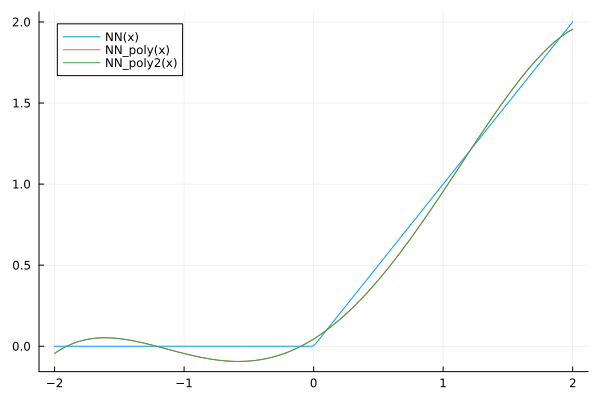

In [10]:
xs = range(-2, 2, 200)
ys = [nn([x])[1] for x in xs];
ys_poly = [nn_poly([x])[1] for x in xs];
ys_poly2 = [nn_poly2([x])[1] for x in xs];

plot(xs, ys, label="NN(x)")
plot!(xs, ys_poly, label="NN_poly(x)")
plot!(xs, ys_poly2, label="NN_poly2(x)")

In [11]:
params_nn_poly2 = convert_to_list_of_tuples(nn_poly2)
@save "just_relu.jld2" params_nn_poly2

## Small Example

In [67]:
W1 = [1. 1; 1 -1]
b1 = [0., 0.]

W2 = [1. 1; 1 -1]
b2 = [-0.5, 0]

W3 = [-1. 1; 0 1]
b3 = [3., 0]

nn = Network([Dense(W1, b1), ReLU(), Dense(W2, b2), ReLU(), Dense(W3, b3)])

z = Zonotope(-ones(2), ones(2))
degree = 5
nn_poly = approximate_polynomial_iterative(nn, z, degree, cheby=true, verbosity=1, max_iter=20)

--- layer 1 ---
lower = [-1.0, -1.0]
upper = [1.0, 1.0]
--- layer 2 ---
lower = [-2.0, -2.0]
upper = [2.0, 2.0]
max error = 0.044658198738520616 at idx 1 with bounds -2.0 2.0
--- layer 3 ---
lower = [-0.9553418012613971, -0.9553418012613971]
upper = [1.9564367779954268, 1.9564367779954268]
--- layer 4 ---
lower = [-1.4106836025228766, -1.9117785792569062]
upper = [2.412873555990936, 1.9117785792569062]
max error = 0.05272492855818767 at idx 1 with bounds -1.4106836025228766 2.412873555990936
--- layer 5 ---
lower = [-0.8445071865604521, -0.9132009957604309]
upper = [2.368354548877394, 1.8701369619215886]


Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0 1.0; 1.0 -1.0], [0.0, 0.0]), ChebyshevPoly{Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}([0.6220084679281463 1.0000000000000002 … -0.1220084679281462 -5.551115123125783e-18; 0.6220084679281463 1.0000000000000002 … -0.1220084679281462 -5.551115123125783e-18], [-2.0, -2.0], [2.0, 2.0]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([1.0 1.0; 1.0 -1.0], [-0.5, 0.0]), ChebyshevPoly{Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}([0.8717732763416244 1.25972925015921 … -0.06853362124847143 0.06792266583018995; 0.5945712325507181 0.9558892896284533 … -0.11662658773649151 -5.828670879282072e-17], [-1.4106836025228766, -1.9117785792569062], [2.412873555990936, 1.9117785792569062]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([-1.0 1.0; 0.0 1.0], [3.0, 0.0])])

In [13]:
nn_poly2 = merge_normalization_into_dense(nn_poly)

Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([0.5 0.5; 0.5 -0.5], [0.0, 0.0]), ChebyshevPoly{Float64, Vector{Float64}}([0.6220084679281463 1.0000000000000002 … -0.1220084679281462 -5.551115123125783e-18; 0.6220084679281463 1.0000000000000002 … -0.1220084679281462 -5.551115123125783e-18], [-1.0, -1.0], [1.0, 1.0]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([0.5230731272178457 0.5230731272178457; 0.5230731272178457 -0.5230731272178457], [-0.5236458801223454, 0.0]), ChebyshevPoly{Float64, Vector{Float64}}([0.8717732763416244 1.25972925015921 … -0.06853362124847143 0.06792266583018995; 0.5945712325507181 0.9558892896284533 … -0.11662658773649151 -5.828670879282072e-17], [-1.0, -1.0], [1.0, 1.0]), Dense{Float64, Matrix{Float64}, Vector{Float64}}([-1.0 1.0; 0.0 1.0], [3.0, 0.0])])

In [14]:
xs = 2 .* rand(5, 2) .- 1
ys = [nn(xs[i,:]) for i in 1:5];
ys_poly = [nn_poly(xs[i,:]) for i in 1:5];
ys_poly2 = [nn_poly2(xs[i,:]) for i in 1:5];

# just sanity check 
@show first.(ys)
@show first.(ys_poly)
@show first.(ys_poly2);

first.(ys) = [3.2089218276042604, 3.5, 3.0, 3.166371105352815, 3.0]
first.(ys_poly) = [3.1602373560109767, 3.475686891762128, 3.0519080383548163, 3.2134054899108584, 3.072375563948935]
first.(ys_poly2) = [3.1602373560109767, 3.475686891762128, 3.0519080383548163, 3.2134054899108584, 3.072375563948935]


In [15]:
params_nn_poly2 = convert_to_list_of_tuples(nn_poly2)
@save "simple_nn.jld2" params_nn_poly2

## MNIST

In [122]:
nn = load_network("../networks/mnist/mnist_256x4_1e4.onnx")
nn_poly = generate_poly_network(nn, Zonotope(zeros(784), ones(784)), 50, nothing, nothing, nothing, nothing, cheby=true, verbosity=1, max_iter=20)

Found input input
op: flatten, weight: nothing, bias: nothing
op: gemm, weight: (256, 784), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (256, 256), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (256, 256), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (256, 256), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (10, 256), bias: (10,)
--- layer 1 ---
lower = [0.0, 0.0, 0.0, 0.0, 0.0]
upper = [1.0, 1.0, 1.0, 1.0, 1.0]
--- layer 2 ---
lower = [-0.03516253067573416, -4.180390461351635, -0.0414179974113722, -0.03547903354910886, -0.5818735467182705]
upper = [0.037128060079339775, 0.10925236971979757, 0.04384775429525689, 0.037085272194417485, 0.031826429766169895]
max error = 0.026295025189171817

┌ Warning: Flatten layer is not supported
└ @ VNNLib.NNLoader /home/philipp/.julia/packages/VNNLib/Oj1Tb/src/NNLoader/Main.jl:83


 at idx 224 with bounds -11.348544438988029 7.664086024898552
--- layer 3 ---
lower = [-0.017973627909248134, -0.10807413734831875, -0.02119802097175489, -0.018046584033922692, -0.03043151721953629]
upper = [0.037231283817928805, 0.11117603521947264, 0.04396952968362384, 0.037188723482046424, 0.032221836966506136]
--- layer 4 ---
lower = [-8.190480459761456, -0.013859860242119847, -0.019062927822551732, -0.012028268732297473, -0.018199223295227513]
upper = [7.767532029847193, 0.013393772022488822, 0.020067887858273754, 0.011555986572021093, 0.013040422048590098]
max error = 0.06737896172627345 at idx 110 with bounds -22.58984034216802 25.540095421706116
--- layer 5 ---
lower = [-3.9598893417730046, -0.006765637767730826, -0.009729932362492717, -0.005854086199494511, -0.007545319760537586]
upper = [7.782404700373705, 0.013418649900298913, 0.020123743819977932, 0.01157770847387451, 0.013067360317138413]
--- layer 6 ---
lower = [-0.02646907005916256, -5.445852993970519, -0.016876506977981

Network(Layer[Dense{Float32, Adjoint{Float32, Base.ReshapedArray{Float32, 2, Base.ReinterpretArray{Float32, 1, UInt8, Vector{UInt8}, false}, Tuple{}}}, Base.ReinterpretArray{Float32, 1, UInt8, Vector{UInt8}, false}}(Float32[-0.0003801771 -4.841215f-6 … 0.0004506546 -0.00022187836; 3.7874255f-5 0.00011331283 … 5.9664555f-5 9.1568356f-5; … ; 0.0001204156 0.00010237807 … -5.8376674f-5 -8.800079f-5; -3.618829f-5 2.6539405f-5 … -0.00010940937 8.683106f-5], Float32[5.357947f-5, -0.011604446, -1.580469f-5, -1.590158f-5, -0.012993222, 0.0027697135, 0.00019727921, 1.7287417f-5, 0.00010886912, -0.001721526  …  -0.012317988, -4.520234f-6, 2.2818818f-5, -1.0354297f-6, -1.8209681f-5, -0.025091257, -0.0005246656, 0.000244161, 0.0027211416, -0.00064625667]), ChebyshevPoly{Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}([0.012000596468824192 0.018698242165687648 … 0.00010752734533926008 1.3001021064404921e-5; 0.007410642175168014 0.014670516192683267 

In [123]:
nn_poly2 = merge_normalization_into_dense(nn_poly)

Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([-0.010518024685250224 -0.00013393761985119347 … 0.012467863131773478 -0.0061385129272966835; 1.7658465613322518e-5 5.2830893449500446e-5 … 2.7817959377976125e-5 4.269276462494032e-5; … ; 1.639619424431407e-5 1.3940143558298584e-5 … -7.948764869859634e-6 -1.1982483938452538e-5; -0.000513585380124413 0.0003766481031706886 … -0.001552741343505525 0.0012323092564637678], [-0.02570694804202523, 0.9436518048398632, -0.02886699775513836, -0.022573657782905866, 0.8539362764018972, 0.19858927519138547, -0.0166733260016375, -0.11183603883974191, -0.08581267487853292, 0.7972456957561024  …  0.8836042578520413, 0.04712420401854281, 0.021394878564015306, -0.03132435379252066, -0.03216292071625758, -0.13669916630262613, 0.11910965577754673, 0.020970372650656485, 0.13037407123651887, 0.5010759328561959]), ChebyshevPoly{Float64, Vector{Float64}}([0.012000596468824192 0.018698242165687648 … 0.00010752734533926008 1.3001021064404921e-5; 0.0

In [124]:
xs = rand(5, 784)
ys = [nn(xs[i,:]) for i in 1:5];
ys_poly = [nn_poly(xs[i,:]) for i in 1:5];
ys_poly2 = [nn_poly2(xs[i,:]) for i in 1:5];

# just sanity check 
@show first.(ys)
@show first.(ys_poly)
@show first.(ys_poly2);

first.(ys) = [1.2411553319257216, 3.952146273572779, 3.6709600154053983, 4.3221200521483105, 4.207106647583648]
first.(ys_poly) = [1.933729267126628, 4.72795601068584, 3.5665755137449806, 4.491329651428681, 4.423230250560737]
first.(ys_poly2) = [1.933729267126627, 4.727956010685836, 3.566575513744979, 4.491329651428689, 4.423230250560744]


In [125]:
params_nn_poly2 = convert_to_list_of_tuples(nn_poly2)
@save "mnist_256x4_1e4.jld2" params_nn_poly2